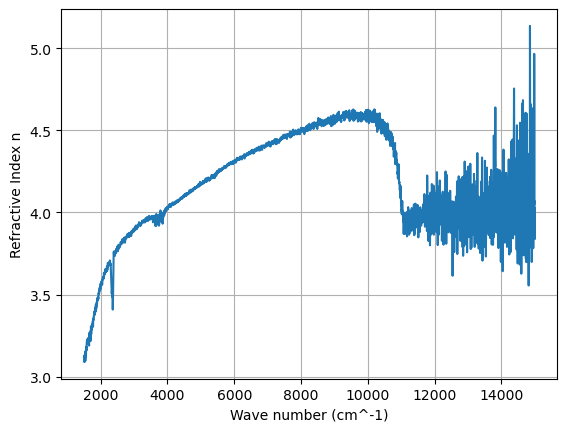

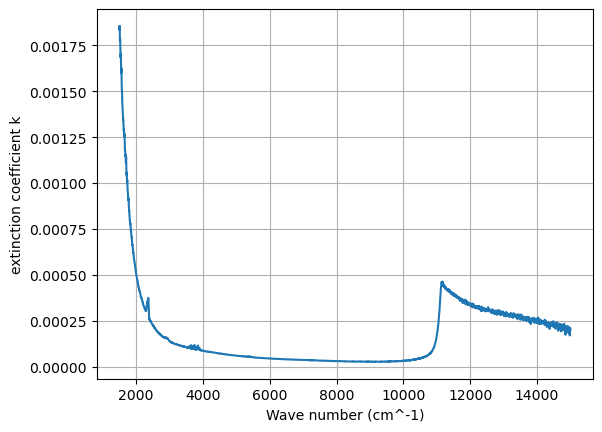

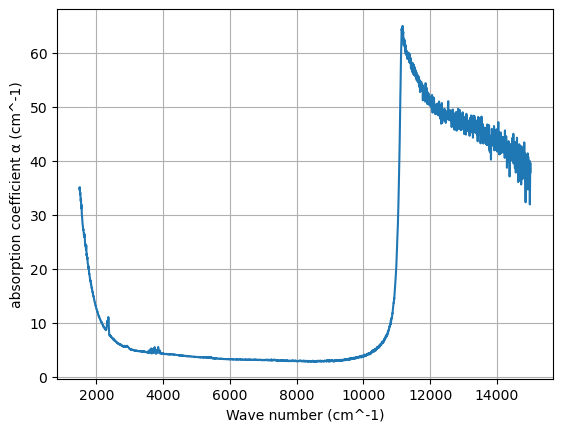

   wavenumber_cm^-1        R        T  alpha_cm^-1         k         n
0        1499.54713  0.26467  0.11677    34.907462  0.001852  3.119131
1        1500.51147  0.26510  0.11740    34.759797  0.001843  3.122678
2        1501.47581  0.26551  0.11782    34.654206  0.001837  3.126063
3        1502.44015  0.26568  0.11790    34.628528  0.001834  3.127468
4        1503.40448  0.26540  0.11765    34.693504  0.001836  3.125155


In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def _load_two_column_file(filename, skiprows=0, decimal='.', comment='#'):
    """
    Liest eine Datei mit zwei Spalten ein:
    Spalte 1: Wellenzahl
    Spalte 2: Intensität (R oder T)

    Unterstützt whitespace-, tab- oder komma-separierte Dateien.
    """
    try:
        df = pd.read_csv(
            filename,
            sep=None,              # automatische Trennzeichenerkennung
            engine="python",
            skiprows=skiprows,
            comment=comment,
            decimal=decimal,
            header=None
        )
    except Exception as e:
        raise ValueError(f"Datei '{filename}' konnte nicht gelesen werden: {e}")

    if df.shape[1] < 2:
        raise ValueError(f"Datei '{filename}' muss mindestens 2 Spalten haben.")

    df = df.iloc[:, :2].copy()
    df.columns = ["wavenumber_cm^-1", "value"]

    # numerisch erzwingen
    df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna()

    if df.empty:
        raise ValueError(f"Datei '{filename}' enthält keine gültigen numerischen Daten.")

    return df.sort_values("wavenumber_cm^-1").reset_index(drop=True)


def _normalize_if_percent(values):
    """
    Wenn die Werte offensichtlich in Prozent vorliegen (>1),
    werden sie nach [0,1] umgerechnet.
    """
    values = np.asarray(values, dtype=float)
    if np.nanmax(values) > 1.0:
        values = values / 100.0
    return values


def _interpolate_to_common_grid(df_r, df_t):
    """
    Bringt Reflexion und Transmission auf dieselbe Wellenzahl-Achse.
    Es wird auf den gemeinsamen Bereich interpoliert.
    """
    wn_r = df_r["wavenumber_cm^-1"].to_numpy()
    r = df_r["value"].to_numpy()

    wn_t = df_t["wavenumber_cm^-1"].to_numpy()
    t = df_t["value"].to_numpy()

    wn_min = max(np.min(wn_r), np.min(wn_t))
    wn_max = min(np.max(wn_r), np.max(wn_t))

    if wn_min >= wn_max:
        raise ValueError("Reflexions- und Transmissionsdaten haben keinen gemeinsamen Wellenzahlbereich.")

    # gemeinsame Achse: die feinere von beiden im Überlappungsbereich
    wn_common = np.unique(np.concatenate([
        wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
        wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
    ]))

    r_interp = np.interp(wn_common, wn_r, r)
    t_interp = np.interp(wn_common, wn_t, t)

    return wn_common, r_interp, t_interp


def _alpha_from_R_T(R, T, thickness_cm):
    """
    Bestimmt alpha aus R und T für eine planparallele Platte
    unter Vernachlässigung kohärenter Interferenz.

    Verwendete Gleichung:
    T = ((1-R)^2 * x) / (1 - R^2 * x^2), mit x = exp(-alpha * d)

    Daraus folgt eine quadratische Gleichung in x.
    """
    R = np.asarray(R, dtype=float)
    T = np.asarray(T, dtype=float)

    eps = 1e-15

    # Werte physikalisch begrenzen
    R = np.clip(R, 0.0, 0.999999)
    T = np.clip(T, 0.0, 0.999999)

    alpha = np.full_like(R, np.nan, dtype=float)

    # Spezialfall R ~ 0 -> T ~ exp(-alpha d)
    mask_r0 = np.abs(R) < 1e-10
    alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

    # allgemeiner Fall
    mask = ~mask_r0
    Rm = R[mask]
    Tm = T[mask]

    a = Tm * Rm**2
    b = (1.0 - Rm)**2
    c = -Tm

    disc = b**2 - 4.0 * a * c
    disc = np.maximum(disc, 0.0)

    # physikalisch sinnvoller positiver Ast
    x = (-b + np.sqrt(disc)) / (2.0 * a)

    # numerisch absichern: x = exp(-alpha d) muss zwischen 0 und 1 liegen
    x = np.clip(x, eps, 1.0)

    alpha[mask] = -np.log(x) / thickness_cm
    return alpha


def _k_from_alpha(alpha_cm_inv, wavenumber_cm_inv):
    """
    alpha = 4 * pi * k * wavenumber
    => k = alpha / (4 * pi * wavenumber)
    """
    alpha_cm_inv = np.asarray(alpha_cm_inv, dtype=float)
    wn = np.asarray(wavenumber_cm_inv, dtype=float)

    k = np.full_like(alpha_cm_inv, np.nan, dtype=float)
    mask = wn > 0
    k[mask] = alpha_cm_inv[mask] / (4.0 * np.pi * wn[mask])
    return k


def _n_from_R_k(R, k):
    """
    Aus
    R = [ (n-1)^2 + k^2 ] / [ (n+1)^2 + k^2 ]

    folgt für n:
    n = (1+R)/(1-R) + sqrt( 4R/(1-R)^2 - k^2 )

    Der positive Ast wird verwendet.
    """
    R = np.asarray(R, dtype=float)
    k = np.asarray(k, dtype=float)

    eps = 1e-15
    R = np.clip(R, 0.0, 0.999999)

    term1 = (1.0 + R) / np.clip(1.0 - R, eps, None)
    term2 = 4.0 * R / np.clip((1.0 - R)**2, eps, None) - k**2

    # kann durch Messrauschen leicht negativ werden
    term2 = np.maximum(term2, 0.0)

    n = term1 + np.sqrt(term2)
    return n


def analyze_semiconductor_rt(
    reflection_file,
    transmission_file,
    thickness_cm,
    output_file=None,
    skiprows_reflection=0,
    skiprows_transmission=0,
    decimal='.',
    comment='#'
):
    """
    Liest Reflexions- und Transmissionsdaten ein und berechnet:
    - Brechungsindex n
    - Extinktionskoeffizient k
    - Absorptionskoeffizient alpha [cm^-1]

    Parameter
    ---------
    reflection_file : str
        Datei mit Reflexionsdaten: Spalte 1 = Wellenzahl [cm^-1], Spalte 2 = R
    transmission_file : str
        Datei mit Transmissionsdaten: Spalte 1 = Wellenzahl [cm^-1], Spalte 2 = T
    thickness_cm : float
        Probendicke in cm
    output_file : str oder None
        Wenn gesetzt, wird das Ergebnis als CSV gespeichert
    skiprows_reflection : int
        Anzahl zu überspringender Kopfzeilen in Reflexionsdatei
    skiprows_transmission : int
        Anzahl zu überspringender Kopfzeilen in Transmissionsdatei
    decimal : str
        Dezimaltrennzeichen, z. B. '.' oder ','
    comment : str
        Kommentarzeichen in den Dateien

    Returns
    -------
    result_df : pandas.DataFrame
        Tabelle mit:
        wavenumber_cm^-1, R, T, alpha_cm^-1, k, n
    """
    if thickness_cm <= 0:
        raise ValueError("thickness_cm muss > 0 sein.")

    df_r = _load_two_column_file(
        reflection_file,
        skiprows=skiprows_reflection,
        decimal=decimal,
        comment=comment
    )
    df_t = _load_two_column_file(
        transmission_file,
        skiprows=skiprows_transmission,
        decimal=decimal,
        comment=comment
    )

    wn, R, T = _interpolate_to_common_grid(df_r, df_t)

    R = _normalize_if_percent(R)
    T = _normalize_if_percent(T)

    # grobe physikalische Begrenzung
    R = np.clip(R, 0.0, 0.999999)
    T = np.clip(T, 0.0, 0.999999)

    alpha = _alpha_from_R_T(R, T, thickness_cm)
    k = _k_from_alpha(alpha, wn)
    n = _n_from_R_k(R, k)

    result_df = pd.DataFrame({
        "wavenumber_cm^-1": wn,
        "R": R,
        "T": T,
        "alpha_cm^-1": alpha,
        "k": k,
        "n": n
    })

    if output_file is not None:
        output_path = Path(output_file)
        result_df.to_csv(output_path, index=False)

    return result_df

    


def plot_optical_properties(result_df, title_prefix=""):
    """
    Plottet n, k und alpha gegen die Wellenzahl.
    """
    wn = result_df["wavenumber_cm^-1"]

    # Brechungsindex n
    plt.figure()
    plt.plot(wn, result_df["n"])
    plt.xlabel("Wave number (cm^-1)")
    plt.ylabel("Refractive Index n")
    #plt.title(f"{title_prefix} n(ν̃)")
    plt.grid()
    plt.show()

    # Extinktionskoeffizient k
    plt.figure()
    plt.plot(wn, result_df["k"])
    plt.xlabel("Wave number (cm^-1)")
    plt.ylabel("extinction coefficient k")
    #plt.title(f"{title_prefix} k(ν̃)")
    plt.grid()
    plt.show()

    # Absorptionskoeffizient alpha
    plt.figure()
    plt.plot(wn, result_df["alpha_cm^-1"])
    plt.xlabel("Wave number (cm^-1)")
    plt.ylabel("absorption coefficient α (cm^-1)")
    #plt.title(f"{title_prefix} α(ν̃)")
    plt.grid()
    plt.show()


if __name__ == "__main__":
    # Beispielaufruf:
    # Probendicke z. B. 500 µm = 0.05 cm
    result = analyze_semiconductor_rt(
        
        reflection_file="reflexion/GaAs_Doped_N50_Res4_Reflex_Normalized.DPT",
        transmission_file="transmission/GaAs_Doped_N50_Res4_Trans_Normalized.DPT",
        thickness_cm=0.044,
        output_file="auswertung_probe1.csv"
    )
    plot_optical_properties(result, title_prefix="Probe 1")
    print(result.head())

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def tauc_plot_from_files(
    reflection_file,
    transmission_file,
    thickness_cm,
    fit_min_eV,
    fit_max_eV,
    transition="auto",
    material=None,
    skiprows_reflection=0,
    skiprows_transmission=0,
    decimal='.',
    comment='#',
    plot_result=True
):
    """
    Lädt Reflexions- und Transmissionsdaten neu, berechnet alpha
    und erstellt daraus einen Tauc-Plot samt linearem Fit zur Bestimmung
    der Bandlücke Eg.

    Parameter
    ---------
    reflection_file : str
        Datei mit Reflexionsdaten (Spalte 1: Wellenzahl [cm^-1], Spalte 2: R)
    transmission_file : str
        Datei mit Transmissionsdaten (Spalte 1: Wellenzahl [cm^-1], Spalte 2: T)
    thickness_cm : float
        Probendicke in cm
    fit_min_eV, fit_max_eV : float
        Energiebereich für linearen Fit
    transition : str
        "direct", "indirect" oder "auto"
    material : str oder None
        Optional, z. B. "Si" oder "GaSb".
        Nur relevant, wenn transition="auto".
    skiprows_reflection : int
        Zu überspringende Zeilen in der Reflexionsdatei
    skiprows_transmission : int
        Zu überspringende Zeilen in der Transmissionsdatei
    decimal : str
        Dezimaltrennzeichen, '.' oder ','
    comment : str
        Kommentarzeichen
    plot_result : bool
        Ob der Tauc-Plot angezeigt wird

    Returns
    -------
    Eg : float
        Bandlücke in eV
    result_df : pandas.DataFrame
        Tabelle mit Wellenzahl, R, T, alpha, Energie und Tauc-Wert
    fit_params : tuple
        (a, b) für y = a*x + b
    used_transition : str
        Verwendeter Übergangstyp ("direct" oder "indirect")
    """

    def _load_two_column_file(filename, skiprows=0, decimal='.', comment='#'):
        df = pd.read_csv(
            filename,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        if df.shape[1] < 2:
            raise ValueError(f"Datei '{filename}' muss mindestens zwei Spalten haben.")

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber_cm^-1", "value"]
        df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna().sort_values("wavenumber_cm^-1").reset_index(drop=True)

        if len(df) == 0:
            raise ValueError(f"Keine gültigen Daten in '{filename}' gefunden.")

        return df

    def _normalize_if_percent(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1.0:
            values = values / 100.0
        return values

    def _interpolate_to_common_grid(df_r, df_t):
        wn_r = df_r["wavenumber_cm^-1"].to_numpy()
        r = df_r["value"].to_numpy()

        wn_t = df_t["wavenumber_cm^-1"].to_numpy()
        t = df_t["value"].to_numpy()

        wn_min = max(np.min(wn_r), np.min(wn_t))
        wn_max = min(np.max(wn_r), np.max(wn_t))

        if wn_min >= wn_max:
            raise ValueError("Kein gemeinsamer Wellenzahlbereich zwischen R- und T-Daten.")

        wn_common = np.unique(np.concatenate([
            wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
            wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
        ]))

        r_interp = np.interp(wn_common, wn_r, r)
        t_interp = np.interp(wn_common, wn_t, t)

        return wn_common, r_interp, t_interp

    def _alpha_from_R_T(R, T, thickness_cm):
        """
        T = ((1-R)^2 * x) / (1 - R^2 * x^2), mit x = exp(-alpha*d)
        """
        eps = 1e-15

        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        T = np.clip(np.asarray(T, dtype=float), 0.0, 0.999999)

        alpha = np.full_like(R, np.nan, dtype=float)

        mask_r0 = np.abs(R) < 1e-10
        alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

        mask = ~mask_r0
        Rm = R[mask]
        Tm = T[mask]

        a = Tm * Rm**2
        b = (1.0 - Rm)**2
        c = -Tm

        disc = b**2 - 4.0 * a * c
        disc = np.maximum(disc, 0.0)

        x = (-b + np.sqrt(disc)) / (2.0 * a)
        x = np.clip(x, eps, 1.0)

        alpha[mask] = -np.log(x) / thickness_cm
        return alpha

    def _decide_transition(transition, material):
        if transition in ("direct", "indirect"):
            return transition

        if transition != "auto":
            raise ValueError("transition muss 'direct', 'indirect' oder 'auto' sein.")

        if material is None:
            raise ValueError("Bei transition='auto' bitte material='Si' oder 'GaSb' angeben.")

        m = material.strip().lower()
        if m in ["si", "silizium", "silicon"]:
            return "indirect"
        elif m in ["gasb", "ga sb", "galliumantimonid", "gallium antimonide"]:
            return "direct"
        else:
            raise ValueError(
                f"Material '{material}' ist für auto nicht hinterlegt. "
                "Bitte transition direkt als 'direct' oder 'indirect' setzen."
            )

    # Daten laden
    df_r = _load_two_column_file(
        reflection_file,
        skiprows=skiprows_reflection,
        decimal=decimal,
        comment=comment
    )
    df_t = _load_two_column_file(
        transmission_file,
        skiprows=skiprows_transmission,
        decimal=decimal,
        comment=comment
    )

    # Gemeinsame Wellenzahlachse
    wn, R, T = _interpolate_to_common_grid(df_r, df_t)

    # Prozent -> Anteil
    R = _normalize_if_percent(R)
    T = _normalize_if_percent(T)

    # alpha berechnen
    alpha = _alpha_from_R_T(R, T, thickness_cm)

    # Energie aus Wellenzahl
    energy_eV = 1.239841984e-4 * wn

    # Übergang wählen
    used_transition = _decide_transition(transition, material)

    # Tauc-Größe berechnen
    alpha_hv = np.clip(alpha * energy_eV, 0, None)

    if used_transition == "direct":
        tauc_y = alpha_hv**2
        y_label = r"$(\alpha h\nu)^2$"
        title_transition = "direkter Übergang"
    else:
        tauc_y = np.sqrt(alpha_hv)
        y_label = r"$(\alpha h\nu)^{1/2}$"
        title_transition = "indirekter Übergang"

    # Fitbereich auswählen
    mask_fit = (
        np.isfinite(energy_eV) &
        np.isfinite(tauc_y) &
        (energy_eV >= fit_min_eV) &
        (energy_eV <= fit_max_eV)
    )

    if np.sum(mask_fit) < 2:
        raise ValueError("Im gewählten Fitbereich liegen zu wenige gültige Punkte.")

    x_fit = energy_eV[mask_fit]
    y_fit = tauc_y[mask_fit]

    # linearer Fit
    a, b = np.polyfit(x_fit, y_fit, 1)

    if np.isclose(a, 0):
        raise ValueError("Fit fehlgeschlagen: Steigung ist nahezu 0.")

    Eg = -b / a

    result_df = pd.DataFrame({
        "wavenumber_cm^-1": wn,
        "R": R,
        "T": T,
        "alpha_cm^-1": alpha,
        "energy_eV": energy_eV,
        "tauc_y": tauc_y
    })

    if plot_result:
        plt.figure(figsize=(7, 5))
        plt.plot(energy_eV, tauc_y)
        plt.plot(x_fit, a * x_fit + b, label=f"linear Fit: Eg = {Eg:.3f} eV")
        plt.axvline(Eg, linestyle="--", label=f"Eg = {Eg:.3f} eV")
        plt.xlabel("Photon energy hν (eV)")
        plt.ylabel(y_label)
        #plt.title(f"Tauc-Plot ({title_transition})")
        plt.grid(True)
        plt.legend()
        plt.show()

    return Eg, result_df, (a, b), used_transition

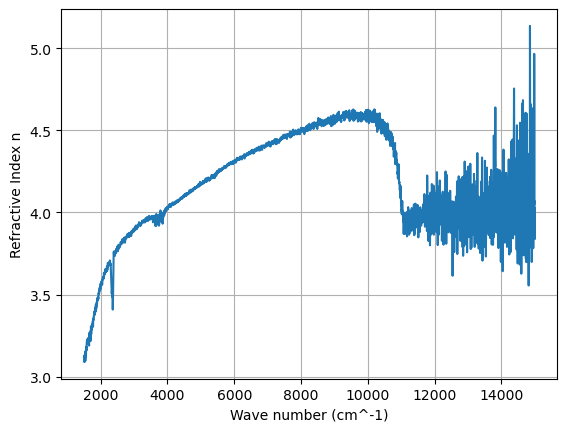

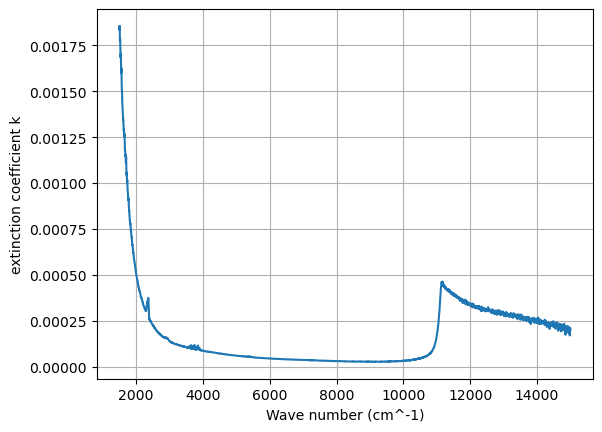

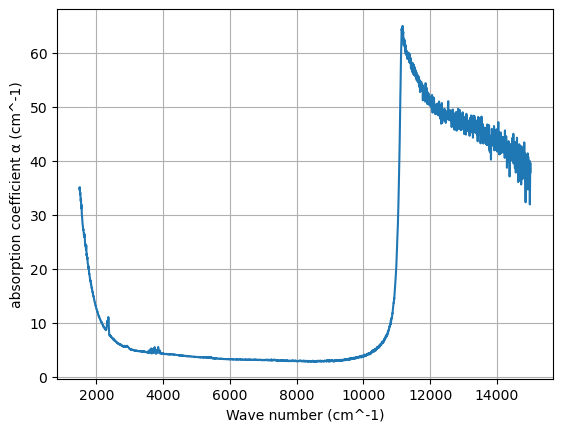

   wavenumber_cm^-1        R        T  alpha_cm^-1         k         n
0        1499.54713  0.26467  0.11677    34.907462  0.001852  3.119131
1        1500.51147  0.26510  0.11740    34.759797  0.001843  3.122678
2        1501.47581  0.26551  0.11782    34.654206  0.001837  3.126063
3        1502.44015  0.26568  0.11790    34.628528  0.001834  3.127468
4        1503.40448  0.26540  0.11765    34.693504  0.001836  3.125155


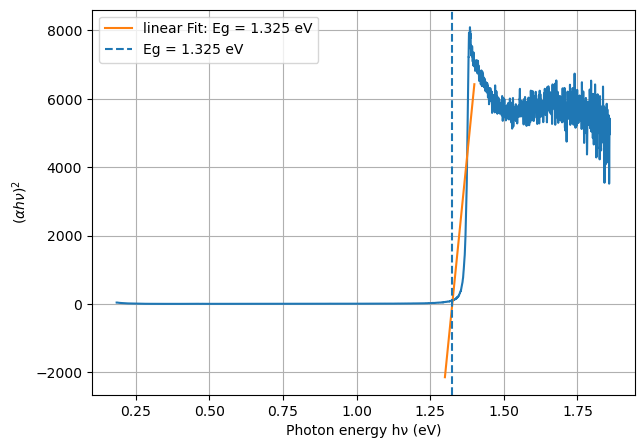

GaSb:
Übergang: direct
Bandlücke Eg = 1.325 eV


In [7]:
#if __name__ == "__main__":
    # Beispielaufruf:
    # Probendicke z. B. 500 µm = 0.05 cm
result = analyze_semiconductor_rt(
        
        reflection_file="reflexion/GaAs_Doped_N50_Res4_Reflex_Normalized.DPT",
        transmission_file="transmission/GaAs_Doped_N50_Res4_Trans_Normalized.DPT",
        thickness_cm=0.044,
        output_file="auswertung_probe1.csv"
)
plot_optical_properties(result, title_prefix="Probe 1")
print(result.head())

Eg_gasb, df_gasb, fit_gasb, trans_gasb = tauc_plot_from_files(
    reflection_file="reflexion/GaAs_Doped_N50_Res4_Reflex_Normalized.DPT",
    transmission_file="transmission/GaAs_Doped_N50_Res4_Trans_Normalized.DPT",
    thickness_cm=0.044,
    fit_min_eV=1.3,
    fit_max_eV=1.4,
    material="GaSb",
    transition="auto"
)

print("GaSb:")
print("Übergang:", trans_gasb)
print(f"Bandlücke Eg = {Eg_gasb:.3f} eV")


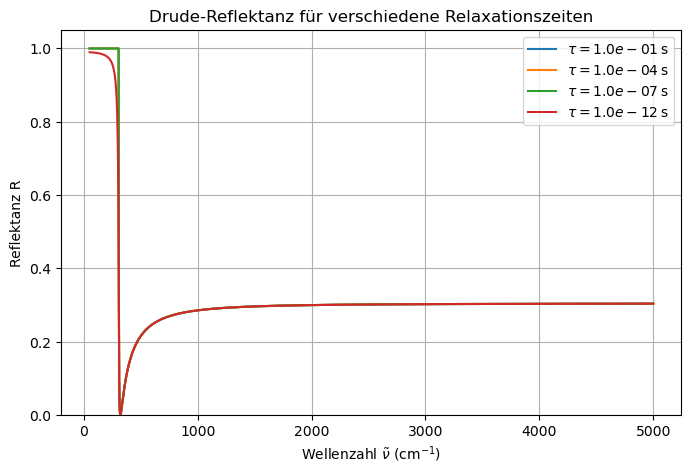

In [97]:
import numpy as np
import matplotlib.pyplot as plt


def drude_epsilon(omega, omega_p, tau, eps_inf=1.0):
    """
    Komplexe Dielektrizitätsfunktion nach dem Drude-Modell.

    Parameter
    ---------
    omega : array_like
        Kreisfrequenz in rad/s
    omega_p : float
        Plasmafrequenz in rad/s
    tau : float
        Relaxationszeit in s
    eps_inf : float
        Hochfrequenz-Dielektrizitätskonstante

    Returns
    -------
    epsilon : ndarray
        Komplexe Dielektrizitätsfunktion
    """
    gamma = 1.0 / tau
    return eps_inf - omega_p**2 / (omega**2 + 1j * gamma * omega)


def reflectance_from_epsilon(epsilon):
    """
    Berechnet die Reflektanz bei normalem Einfall aus epsilon.
    """
    n_complex = np.sqrt(epsilon)
    r = (n_complex - 1.0) / (n_complex + 1.0)
    R = np.abs(r)**2
    return R


def drude_reflectance_vs_wavenumber(wavenumber_cm, omega_p, tau, eps_inf=1.0):
    """
    Berechnet die Reflektanz als Funktion der Wellenzahl.

    Parameter
    ---------
    wavenumber_cm : array_like
        Wellenzahl in cm^-1
    omega_p : float
        Plasmafrequenz in rad/s
    tau : float
        Relaxationszeit in s
    eps_inf : float
        Hochfrequenz-Dielektrizitätskonstante

    Returns
    -------
    R : ndarray
        Reflektanz
    """
    c_cm_s = 2.99792458e10  # Lichtgeschwindigkeit in cm/s
    omega = 2.0 * np.pi * c_cm_s * np.asarray(wavenumber_cm)

    epsilon = drude_epsilon(omega, omega_p, tau, eps_inf=eps_inf)
    R = reflectance_from_epsilon(epsilon)
    return R


def plot_drude_reflectance_four_taus(
    wavenumber_min=50,
    wavenumber_max=5000,
    num_points=2000,
    omega_p=2.0e14,
    eps_inf=12.0,
    taus=(1e-15, 5e-15, 1e-14, 5e-14)
):
    """
    Plottet die Drude-Reflektanz für vier verschiedene Relaxationszeiten.

    Parameter
    ---------
    wavenumber_min : float
        Minimale Wellenzahl in cm^-1
    wavenumber_max : float
        Maximale Wellenzahl in cm^-1
    num_points : int
        Anzahl der Punkte
    omega_p : float
        Plasmafrequenz in rad/s
    eps_inf : float
        Hochfrequenz-Dielektrizitätskonstante
    taus : tuple
        Vier Relaxationszeiten in s
    """
    wavenumber_cm = np.linspace(wavenumber_min, wavenumber_max, num_points)

    plt.figure(figsize=(8, 5))

    for tau in taus:
        R = drude_reflectance_vs_wavenumber(
            wavenumber_cm=wavenumber_cm,
            omega_p=omega_p,
            tau=tau,
            eps_inf=eps_inf
        )
        plt.plot(wavenumber_cm, R, label=fr"$\tau = {tau:.1e}\,$s")

    plt.xlabel(r"Wellenzahl $\tilde{\nu}$ (cm$^{-1}$)")
    plt.ylabel("Reflektanz R")
    plt.title("Drude-Reflektanz für verschiedene Relaxationszeiten")
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1.05)
    plt.show()


if __name__ == "__main__":
    plot_drude_reflectance_four_taus(
        wavenumber_min=50,
        wavenumber_max=5000,
        num_points=2000,
        omega_p=2.0e14,      # Beispielwert
        eps_inf=12.0,        # Beispielwert
        taus=(0.1, 0.0001, 0.0000001, 0.000000000001)
    )

Read order:
0: key='GaAs_Doped' | transmission='GaAs_Doped_N50_Res4_Trans_Normalized.DPT' | reflection='GaAs_Doped_N50_Res4_Reflex_Normalized.DPT'
1: key='GaAs_UnDop' | transmission='GaAs_UnDoped_N50_Res4_Trans_Normalized.DPT' | reflection='GaAs_UnDoped_N50_Res4_Reflex_Normalized.DPT'
2: key='GaSb_Doped' | transmission='GaSb_Doped_N50_Res4_Trans.DPT' | reflection='GaSb_Doped_N50_Res4_Reflex_Normalized.DPT'
3: key='Si_Doped_N' | transmission='Si_Doped_N50_Res4_Trans_Normalized.DPT' | reflection='Si_Doped_N50_Res4_Reflex_Normalized.DPT'
4: key='Si_UnDoped' | transmission='Si_UnDoped_N50_Res4_Trans_Normalized.DPT' | reflection='Si_UnDoped_N50_Res4_Reflex_Normalized.DPT'


C:\Users\lucas\AppData\Local\Temp\ipykernel_23108\2791423291.py:140: RuntimeWarning: invalid value encountered in divide
  x = (-b + np.sqrt(disc)) / (2.0 * a)
C:\Users\lucas\AppData\Local\Temp\ipykernel_23108\2791423291.py:140: RuntimeWarning: invalid value encountered in divide
  x = (-b + np.sqrt(disc)) / (2.0 * a)



Band gap results:
0: label='GaAs n-doped', transition='direct', Eg=0.2320 eV
1: label='GaAs undoped', transition='direct', fit not available
2: label='GaSb doped', transition='indirect', Eg=-253.7915 eV
3: label='Si n-doped', transition='indirect', Eg=-0.3250 eV
4: label='Si undoped', transition='indirect', Eg=1.0618 eV


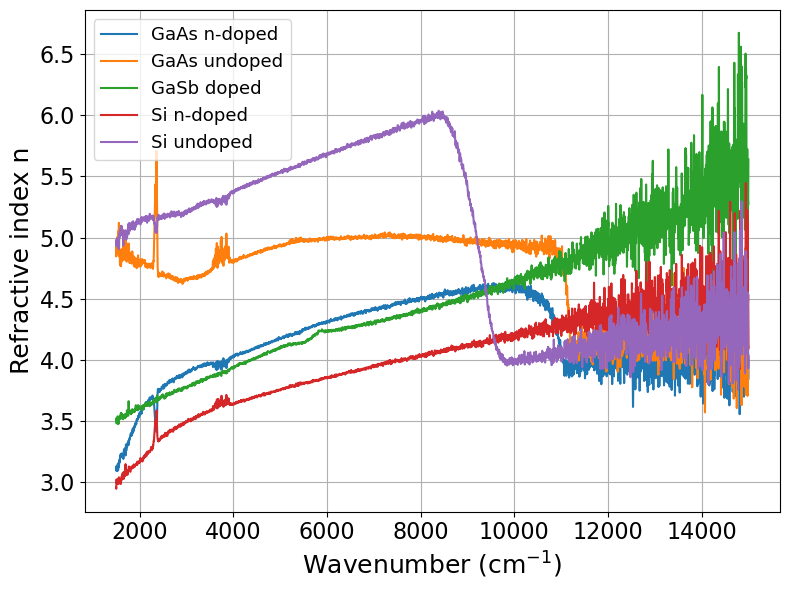

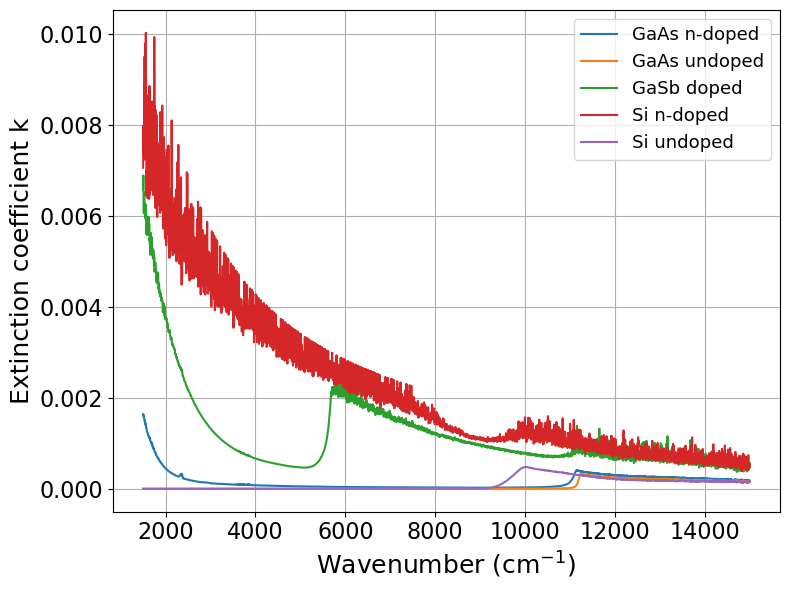

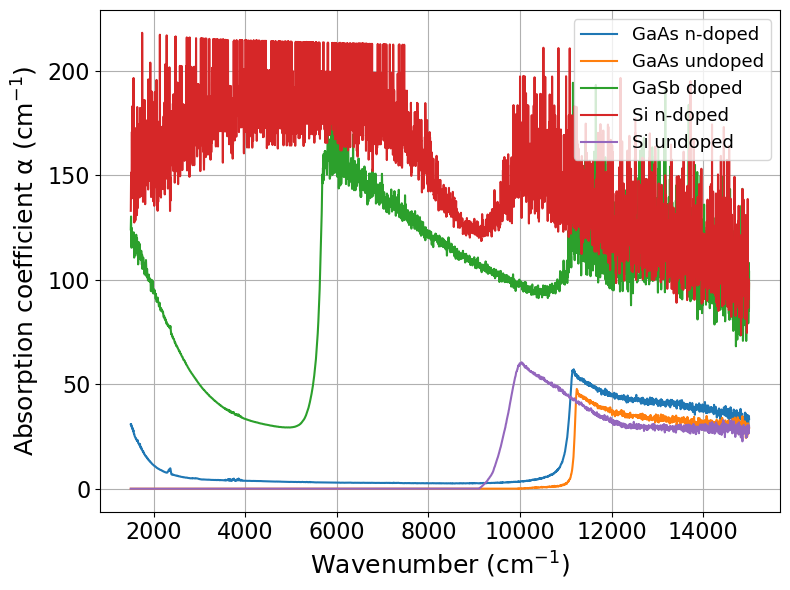

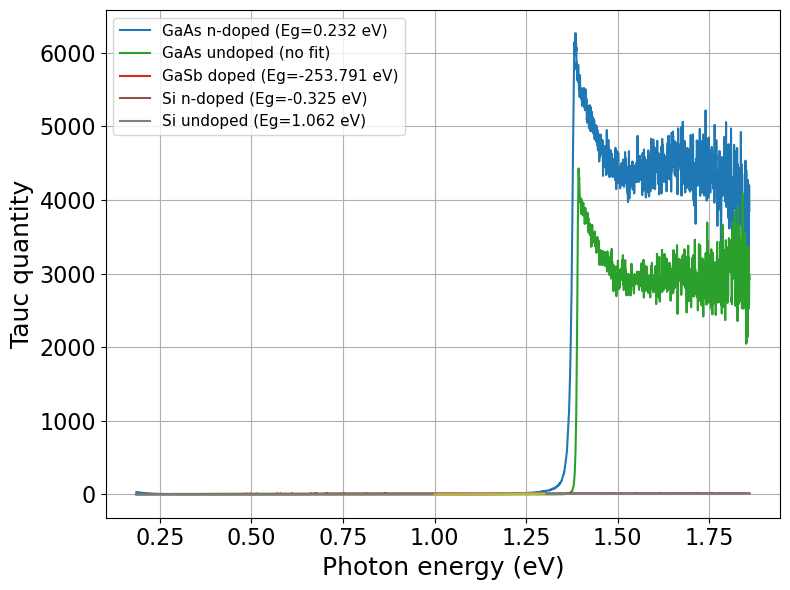

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def analyze_optical_data(
    transmission_dir,
    reflection_dir,
    thickness_list_cm,
    fit_ranges_eV,
    labels_list,
    transition_list=None,
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0,
    save_results=False,
    output_dir="results"
):
    """
    Reads all transmission and reflection files from two folders, pairs them by the
    first 10 characters of the filename, computes n, k, alpha, and creates combined plots.

    Parameters
    ----------
    transmission_dir : str
        Folder containing transmission files.
    reflection_dir : str
        Folder containing reflection files.
    thickness_list_cm : list of float
        Sample thicknesses in cm, in the same order as the automatically read file pairs.
    fit_ranges_eV : list of tuple
        List of (fit_min_eV, fit_max_eV) for the Tauc fit, in the same order as the file pairs.
    labels_list : list of str
        Labels for the legend, in the same order as the automatically read file pairs.
    transition_list : list of str or None
        List with "direct" or "indirect" for each sample.
        If None, all samples are treated as "direct".
    decimal : str
        Decimal separator for file reading, "." or ",".
    comment : str
        Comment character in the files.
    skiprows_transmission : int
        Number of header rows to skip in transmission files.
    skiprows_reflection : int
        Number of header rows to skip in reflection files.
    save_results : bool
        If True, saves per-sample result tables as CSV files.
    output_dir : str
        Folder for saved CSV results.

    Returns
    -------
    results : list of dict
        One entry per sample with computed arrays and fit results.
    """

    def load_two_column_file(filename, skiprows=0, decimal='.', comment='#'):
        df = pd.read_csv(
            filename,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        if df.shape[1] < 2:
            raise ValueError(f"File '{filename}' must contain at least two columns.")

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber_cm^-1", "value"]
        df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna().sort_values("wavenumber_cm^-1").reset_index(drop=True)

        if df.empty:
            raise ValueError(f"No valid numeric data found in '{filename}'.")

        return df

    def normalize_if_percent(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1.0:
            values = values / 100.0
        return values

    def interpolate_to_common_grid(df_r, df_t):
        wn_r = df_r["wavenumber_cm^-1"].to_numpy()
        r = df_r["value"].to_numpy()

        wn_t = df_t["wavenumber_cm^-1"].to_numpy()
        t = df_t["value"].to_numpy()

        wn_min = max(np.min(wn_r), np.min(wn_t))
        wn_max = min(np.max(wn_r), np.max(wn_t))

        if wn_min >= wn_max:
            raise ValueError("No overlapping wavenumber range between reflection and transmission data.")

        wn_common = np.unique(np.concatenate([
            wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
            wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
        ]))

        r_interp = np.interp(wn_common, wn_r, r)
        t_interp = np.interp(wn_common, wn_t, t)

        return wn_common, r_interp, t_interp

    def alpha_from_R_T(R, T, thickness_cm):
        """
        Incoherent multiple-reflection model for a plane-parallel slab:
        T = ((1-R)^2 * x) / (1 - R^2 * x^2), with x = exp(-alpha*d)
        """
        eps = 1e-15

        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        T = np.clip(np.asarray(T, dtype=float), 0.0, 0.999999)

        alpha = np.full_like(R, np.nan, dtype=float)

        mask_r0 = np.abs(R) < 1e-12
        alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

        mask = ~mask_r0
        Rm = R[mask]
        Tm = T[mask]

        a = Tm * Rm**2
        b = (1.0 - Rm)**2
        c = -Tm

        disc = b**2 - 4.0 * a * c
        disc = np.maximum(disc, 0.0)

        # physically meaningful solution
        x = (-b + np.sqrt(disc)) / (2.0 * a)
        x = np.clip(x, eps, 1.0)

        alpha[mask] = -np.log(x) / thickness_cm
        return alpha

    def k_from_alpha(alpha_cm_inv, wavenumber_cm_inv):
        alpha_cm_inv = np.asarray(alpha_cm_inv, dtype=float)
        wn = np.asarray(wavenumber_cm_inv, dtype=float)

        k = np.full_like(alpha_cm_inv, np.nan, dtype=float)
        mask = wn > 0
        k[mask] = alpha_cm_inv[mask] / (4.0 * np.pi * wn[mask])
        return k

    def n_from_R_k(R, k):
        eps = 1e-15
        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        k = np.asarray(k, dtype=float)

        term1 = (1.0 + R) / np.clip(1.0 - R, eps, None)
        term2 = 4.0 * R / np.clip((1.0 - R)**2, eps, None) - k**2
        term2 = np.maximum(term2, 0.0)

        n = term1 + np.sqrt(term2)
        return n

    def energy_from_wavenumber(wavenumber_cm_inv):
        return 1.239841984e-4 * np.asarray(wavenumber_cm_inv, dtype=float)

    def tauc_y_from_alpha_energy(alpha_cm_inv, energy_eV, transition):
        alpha_cm_inv = np.asarray(alpha_cm_inv, dtype=float)
        energy_eV = np.asarray(energy_eV, dtype=float)

        alpha_hv = np.clip(alpha_cm_inv * energy_eV, 0.0, None)

        if transition == "direct":
            return alpha_hv**2
        elif transition == "indirect":
            return np.sqrt(alpha_hv)
        else:
            raise ValueError("transition must be 'direct' or 'indirect'.")

    def fit_tauc(energy_eV, tauc_y, fit_min_eV, fit_max_eV):
        mask = (
            np.isfinite(energy_eV) &
            np.isfinite(tauc_y) &
            (energy_eV >= fit_min_eV) &
            (energy_eV <= fit_max_eV)
        )

        if np.sum(mask) < 2:
            return np.nan, np.nan, np.nan, np.array([]), np.array([]), False

        x_fit = energy_eV[mask]
        y_fit = tauc_y[mask]

        a, b = np.polyfit(x_fit, y_fit, 1)

        if np.isclose(a, 0.0):
            return np.nan, a, b, x_fit, y_fit, False

        Eg = -b / a
        return Eg, a, b, x_fit, y_fit, True

    def style_axes(ax, xlabel, ylabel):
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True)

    transmission_dir = Path(transmission_dir)
    reflection_dir = Path(reflection_dir)

    if not transmission_dir.exists():
        raise FileNotFoundError(f"Transmission directory not found: {transmission_dir}")
    if not reflection_dir.exists():
        raise FileNotFoundError(f"Reflection directory not found: {reflection_dir}")

    transmission_files = sorted([f for f in transmission_dir.iterdir() if f.is_file()])
    reflection_files = sorted([f for f in reflection_dir.iterdir() if f.is_file()])

    trans_map = {}
    for f in transmission_files:
        key = f.name[:10]
        trans_map.setdefault(key, []).append(f)

    refl_map = {}
    for f in reflection_files:
        key = f.name[:10]
        refl_map.setdefault(key, []).append(f)

    common_keys = sorted(set(trans_map.keys()) & set(refl_map.keys()))

    if len(common_keys) == 0:
        raise ValueError("No matching transmission/reflection file pairs found.")

    pairs = []
    for key in common_keys:
        if len(trans_map[key]) != 1:
            raise ValueError(f"Expected exactly one transmission file for key '{key}', found {len(trans_map[key])}.")
        if len(refl_map[key]) != 1:
            raise ValueError(f"Expected exactly one reflection file for key '{key}', found {len(refl_map[key])}.")
        pairs.append((key, trans_map[key][0], refl_map[key][0]))

    print("Read order:")
    for i, (key, t_file, r_file) in enumerate(pairs):
        print(f"{i}: key='{key}' | transmission='{t_file.name}' | reflection='{r_file.name}'")

    n_samples = len(pairs)

    if len(thickness_list_cm) != n_samples:
        raise ValueError(
            f"thickness_list_cm has length {len(thickness_list_cm)}, but {n_samples} file pairs were found."
        )

    if len(fit_ranges_eV) != n_samples:
        raise ValueError(
            f"fit_ranges_eV has length {len(fit_ranges_eV)}, but {n_samples} file pairs were found."
        )

    if len(labels_list) != n_samples:
        raise ValueError(
            f"labels_list has length {len(labels_list)}, but {n_samples} file pairs were found."
        )

    if transition_list is None:
        transition_list = ["direct"] * n_samples

    if len(transition_list) != n_samples:
        raise ValueError(
            f"transition_list has length {len(transition_list)}, but {n_samples} file pairs were found."
        )

    if save_results:
        Path(output_dir).mkdir(parents=True, exist_ok=True)

    results = []

    for i, (key, t_file, r_file) in enumerate(pairs):
        thickness_cm = thickness_list_cm[i]
        fit_min_eV, fit_max_eV = fit_ranges_eV[i]
        transition = transition_list[i].strip().lower()
        label = labels_list[i]

        if thickness_cm <= 0:
            raise ValueError(f"Thickness must be > 0 for sample index {i}.")

        df_t = load_two_column_file(
            t_file,
            skiprows=skiprows_transmission,
            decimal=decimal,
            comment=comment
        )
        df_r = load_two_column_file(
            r_file,
            skiprows=skiprows_reflection,
            decimal=decimal,
            comment=comment
        )

        wn, R, T = interpolate_to_common_grid(df_r, df_t)

        R = normalize_if_percent(R)
        T = normalize_if_percent(T)

        R = np.clip(R, 0.0, 0.999999)
        T = np.clip(T, 0.0, 0.999999)

        alpha = alpha_from_R_T(R, T, thickness_cm)
        k = k_from_alpha(alpha, wn)
        n = n_from_R_k(R, k)

        energy_eV = energy_from_wavenumber(wn)
        tauc_y = tauc_y_from_alpha_energy(alpha, energy_eV, transition)
        Eg, a, b, x_fit, y_fit, fit_success = fit_tauc(energy_eV, tauc_y, fit_min_eV, fit_max_eV)

        result_df = pd.DataFrame({
            "wavenumber_cm^-1": wn,
            "R": R,
            "T": T,
            "alpha_cm^-1": alpha,
            "k": k,
            "n": n,
            "energy_eV": energy_eV,
            "tauc_y": tauc_y
        })

        if save_results:
            result_df.to_csv(Path(output_dir) / f"{key}_optical_results.csv", index=False)

        results.append({
            "index": i,
            "key": key,
            "label": label,
            "transmission_file": t_file.name,
            "reflection_file": r_file.name,
            "thickness_cm": thickness_cm,
            "fit_min_eV": fit_min_eV,
            "fit_max_eV": fit_max_eV,
            "transition": transition,
            "Eg_eV": Eg,
            "fit_a": a,
            "fit_b": b,
            "x_fit": x_fit,
            "y_fit": y_fit,
            "fit_success": fit_success,
            "data": result_df
        })

    print("\nBand gap results:")
    for res in results:
        if res["fit_success"]:
            print(
                f"{res['index']}: label='{res['label']}', transition='{res['transition']}', "
                f"Eg={res['Eg_eV']:.4f} eV"
            )
        else:
            print(
                f"{res['index']}: label='{res['label']}', transition='{res['transition']}', "
                f"fit not available"
            )

    # Combined plot: refractive index
    fig, ax = plt.subplots(figsize=(8, 6))
    for res in results:
        df = res["data"]
        ax.plot(df["wavenumber_cm^-1"], df["n"], label=res["label"])
    style_axes(ax, "Wavenumber (cm$^{-1}$)", "Refractive index n")
    ax.legend(fontsize=13)
    plt.tight_layout()
    plt.show()

    # Combined plot: extinction coefficient
    fig, ax = plt.subplots(figsize=(8, 6))
    for res in results:
        df = res["data"]
        ax.plot(df["wavenumber_cm^-1"], df["k"], label=res["label"])
    style_axes(ax, "Wavenumber (cm$^{-1}$)", "Extinction coefficient k")
    ax.legend(fontsize=13)
    plt.tight_layout()
    plt.show()

    # Combined plot: absorption coefficient
    fig, ax = plt.subplots(figsize=(8, 6))
    for res in results:
        df = res["data"]
        ax.plot(df["wavenumber_cm^-1"], df["alpha_cm^-1"], label=res["label"])
    style_axes(ax, "Wavenumber (cm$^{-1}$)", "Absorption coefficient α (cm$^{-1}$)")
    ax.legend(fontsize=13)
    plt.tight_layout()
    plt.show()

    # Combined plot: Tauc curves + fit lines
    fig, ax = plt.subplots(figsize=(8, 6))
    for res in results:
        df = res["data"]
        x_fit = res["x_fit"]
        a = res["fit_a"]
        b = res["fit_b"]

        if res["fit_success"]:
            label = f"{res['label']} (Eg={res['Eg_eV']:.3f} eV)"
        else:
            label = f"{res['label']} (no fit)"

        ax.plot(df["energy_eV"], df["tauc_y"], label=label)

        if res["fit_success"] and len(x_fit) > 0:
            ax.plot(x_fit, a * x_fit + b)

    if all(res["transition"] == "direct" for res in results):
        ylabel = r"$(\alpha h\nu)^2$"
    elif all(res["transition"] == "indirect" for res in results):
        ylabel = r"$(\alpha h\nu)^{1/2}$"
    else:
        ylabel = "Tauc quantity"

    style_axes(ax, "Photon energy (eV)", ylabel)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    return results


# -------------------------------------------------------------------
# Example call
# -------------------------------------------------------------------

results = analyze_optical_data(
    transmission_dir="transmission",
    reflection_dir="reflexion",
    thickness_list_cm=[
        0.05,
        0.05,
        0.05,
        0.05,
        0.05
    ],
    fit_ranges_eV=[
        (0.7, 0.9),
        (0.7, 0.9),
        (1.0, 1.3),
        (1.0, 1.3),
        (1.0, 1.3)
    ],
    labels_list=[
        "GaAs n-doped",
        "GaAs undoped",
        "GaSb doped",
        "Si n-doped",
        "Si undoped"
    ],
    transition_list=[
        "direct",
        "direct",
        "indirect",
        "indirect",
        "indirect"
    ],
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0,
    save_results=False
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_transmission_reflection(
    transmission_dir,
    reflection_dir,
    labels_list,
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0
):
    """
    Creates two plots:
    - Transmission vs wavenumber
    - Reflection vs wavenumber

    Files are paired by the first 10 characters of the filename.
    """

    def load_file(file, skiprows):
        df = pd.read_csv(
            file,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber", "value"]

        df["wavenumber"] = pd.to_numeric(df["wavenumber"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

        df = df.dropna().sort_values("wavenumber")

        return df

    def normalize(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1:
            values = values / 100
        return values

    def style(ax, xlabel, ylabel):
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(labelsize=16)
        ax.grid(True)

    transmission_files = sorted(Path(transmission_dir).glob("*"))
    reflection_files = sorted(Path(reflection_dir).glob("*"))

    pairs = []
    for tf in transmission_files:
        key = tf.name[:10]
        for rf in reflection_files:
            if rf.name[:10] == key:
                pairs.append((key, tf, rf))
                break

    print("Read order:")
    for i, (key, tf, rf) in enumerate(pairs):
        print(f"{i}: {tf.name} | {rf.name}")

    if len(labels_list) != len(pairs):
        raise ValueError("labels_list length does not match number of file pairs")

    # --- Transmission plot ---
    fig, ax = plt.subplots()

    for i, (key, tf, rf) in enumerate(pairs):
        df = load_file(tf, skiprows_transmission)
        wn = df["wavenumber"].to_numpy()
        T = normalize(df["value"].to_numpy())

        ax.plot(wn, T, label=labels_list[i])

    style(ax, "Wavenumber (cm$^{-1}$)", "Transmission ")
    ax.legend()
    plt.show()

    # --- Reflection plot ---
    fig, ax = plt.subplots()

    for i, (key, tf, rf) in enumerate(pairs):
        df = load_file(rf, skiprows_reflection)
        wn = df["wavenumber"].to_numpy()
        R = normalize(df["value"].to_numpy())

        ax.plot(wn, R, label=labels_list[i])

    style(ax, "Wavenumber (cm$^{-1}$)", "Reflection")
    ax.legend()
    plt.show()

Read order:
0: GaAs_Doped_N50_Res4_Trans_Normalized.DPT | GaAs_Doped_N50_Res4_Reflex_Normalized.DPT
1: GaAs_UnDoped_N50_Res4_Trans_Normalized.DPT | GaAs_UnDoped_N50_Res4_Reflex_Normalized.DPT
2: GaSb_Doped_N50_Res4_Trans.DPT | GaSb_Doped_N50_Res4_Reflex_Normalized.DPT
3: Si_Doped_N50_Res4_Trans_Normalized.DPT | Si_Doped_N50_Res4_Reflex_Normalized.DPT
4: Si_UnDoped_N50_Res4_Trans_Normalized.DPT | Si_UnDoped_N50_Res4_Reflex_Normalized.DPT


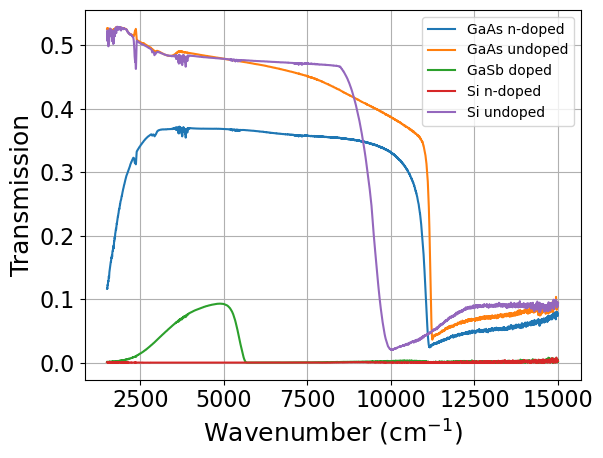

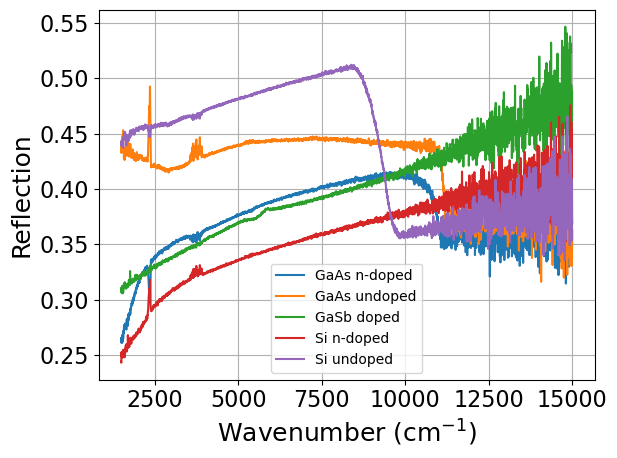

In [15]:
plot_transmission_reflection(
    transmission_dir="transmission",
    reflection_dir="reflexion",
    labels_list=[
        "GaAs n-doped",
        "GaAs undoped",
        "GaSb doped",
        "Si n-doped",
        "Si undoped"
    ],
)



In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_tauc_from_files(
    transmission_file,
    reflection_file,
    thickness_cm,
    fit_min_eV,
    fit_max_eV,
    transition="direct",
    label=None,
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0
):
    """
    Creates a single Tauc plot from one transmission file and one reflection file.

    Parameters
    ----------
    transmission_file : str
        File with transmission data: column 1 = wavenumber (cm^-1), column 2 = transmission
    reflection_file : str
        File with reflection data: column 1 = wavenumber (cm^-1), column 2 = reflection
    thickness_cm : float
        Sample thickness in cm
    fit_min_eV : float
        Lower bound of fit range in eV
    fit_max_eV : float
        Upper bound of fit range in eV
    transition : str
        "direct" or "indirect"
    label : str or None
        Optional label for legend
    decimal : str
        Decimal separator, "." or ","
    comment : str
        Comment character in the data files
    skiprows_transmission : int
        Number of rows to skip in transmission file
    skiprows_reflection : int
        Number of rows to skip in reflection file

    Returns
    -------
    result : dict
        Dictionary with computed data and fit result
    """

    def load_two_column_file(filename, skiprows=0):
        df = pd.read_csv(
            filename,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        if df.shape[1] < 2:
            raise ValueError(f"File '{filename}' must contain at least two columns.")

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber_cm^-1", "value"]
        df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna().sort_values("wavenumber_cm^-1").reset_index(drop=True)

        if df.empty:
            raise ValueError(f"No valid numeric data found in '{filename}'.")

        return df

    def normalize_if_percent(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1.0:
            values = values / 100.0
        return values

    def interpolate_to_common_grid(df_r, df_t):
        wn_r = df_r["wavenumber_cm^-1"].to_numpy()
        r = df_r["value"].to_numpy()

        wn_t = df_t["wavenumber_cm^-1"].to_numpy()
        t = df_t["value"].to_numpy()

        wn_min = max(np.min(wn_r), np.min(wn_t))
        wn_max = min(np.max(wn_r), np.max(wn_t))

        if wn_min >= wn_max:
            raise ValueError("No overlapping wavenumber range between reflection and transmission data.")

        wn_common = np.unique(np.concatenate([
            wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
            wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
        ]))

        r_interp = np.interp(wn_common, wn_r, r)
        t_interp = np.interp(wn_common, wn_t, t)

        return wn_common, r_interp, t_interp

    def alpha_from_R_T(R, T, thickness_cm):
        eps = 1e-15

        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        T = np.clip(np.asarray(T, dtype=float), 0.0, 0.999999)

        alpha = np.full_like(R, np.nan, dtype=float)

        mask_r0 = np.abs(R) < 1e-12
        alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

        mask = ~mask_r0
        Rm = R[mask]
        Tm = T[mask]

        a = Tm * Rm**2
        b = (1.0 - Rm)**2
        c = -Tm

        disc = b**2 - 4.0 * a * c
        disc = np.maximum(disc, 0.0)

        x = (-b + np.sqrt(disc)) / (2.0 * a)
        x = np.clip(x, eps, 1.0)

        alpha[mask] = -np.log(x) / thickness_cm
        return alpha

    def energy_from_wavenumber(wavenumber_cm_inv):
        return 1.239841984e-4 * np.asarray(wavenumber_cm_inv, dtype=float)

    def tauc_y_from_alpha_energy(alpha_cm_inv, energy_eV, transition):
        alpha_hv = np.clip(np.asarray(alpha_cm_inv) * np.asarray(energy_eV), 0.0, None)

        if transition == "direct":
            return alpha_hv**2
        elif transition == "indirect":
            return np.sqrt(alpha_hv)
        else:
            raise ValueError("transition must be 'direct' or 'indirect'.")

    def fit_tauc(energy_eV, tauc_y, fit_min_eV, fit_max_eV):
        mask = (
            np.isfinite(energy_eV) &
            np.isfinite(tauc_y) &
            (energy_eV >= fit_min_eV) &
            (energy_eV <= fit_max_eV)
        )

        if np.sum(mask) < 2:
            return np.nan, np.nan, np.nan, np.array([]), np.array([]), False

        x_fit = energy_eV[mask]
        y_fit = tauc_y[mask]

        a, b = np.polyfit(x_fit, y_fit, 1)

        if np.isclose(a, 0.0):
            return np.nan, a, b, x_fit, y_fit, False

        Eg = -b / a
        return Eg, a, b, x_fit, y_fit, True

    def style_axes(ax, xlabel, ylabel):
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True)

    if thickness_cm <= 0:
        raise ValueError("thickness_cm must be > 0.")

    transition = transition.strip().lower()

    df_t = load_two_column_file(transmission_file, skiprows=skiprows_transmission)
    df_r = load_two_column_file(reflection_file, skiprows=skiprows_reflection)

    wn, R, T = interpolate_to_common_grid(df_r, df_t)

    R = normalize_if_percent(R)
    T = normalize_if_percent(T)

    R = np.clip(R, 0.0, 0.999999)
    T = np.clip(T, 0.0, 0.999999)

    alpha = alpha_from_R_T(R, T, thickness_cm)
    energy_eV = energy_from_wavenumber(wn)
    tauc_y = tauc_y_from_alpha_energy(alpha, energy_eV, transition)

    Eg, a, b, x_fit, y_fit, fit_success = fit_tauc(
        energy_eV, tauc_y, fit_min_eV, fit_max_eV
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    curve_label = label if label is not None else "Sample"

    if fit_success:
        ax.plot(energy_eV/2, tauc_y, label=f"{curve_label} (Eg={Eg/2:.3f} eV)")
        ax.plot(energy_eV/2, a * energy_eV + b, label ='linear fit')
    else:
        ax.plot(energy_eV/2, tauc_y, label=f"{curve_label} (no fit)")

    if transition == "direct":
        ylabel = r"$(\alpha h\nu)^2$"
    else:
        ylabel = r"$(\alpha h\nu)^{1/2}$"
    ax.set_xlim(left=0.75/2)
    ax.set_ylim([0,120000])
    style_axes(ax, "Photon energy (eV)", ylabel)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return {
        "wavenumber_cm^-1": wn,
        "R": R,
        "T": T,
        "alpha_cm^-1": alpha,
        "energy_eV": energy_eV,
        "tauc_y": tauc_y,
        "Eg_eV": Eg,
        "fit_a": a,
        "fit_b": b,
        "x_fit": x_fit,
        "y_fit": y_fit,
        "fit_success": fit_success
    }

C:\Users\lucas\AppData\Local\Temp\ipykernel_23108\214809715.py:129: RuntimeWarning: invalid value encountered in divide
  x = (-b + np.sqrt(disc)) / (2.0 * a)


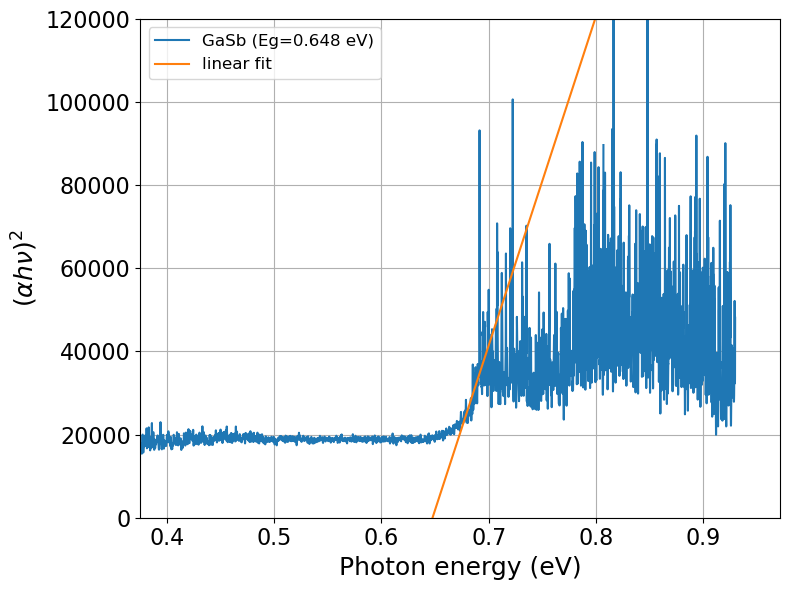

In [83]:
result_si = plot_tauc_from_files(
    transmission_file="transmission/GaSb_Doped_N50_Res4_Trans.DPT",
    reflection_file="reflexion/GaSb_Doped_N50_Res4_Reflex_Normalized.DPT",
    thickness_cm=0.044,
    fit_min_eV=1.35,
    fit_max_eV=1.4,
    transition="direct",
    label="GaSb"
)

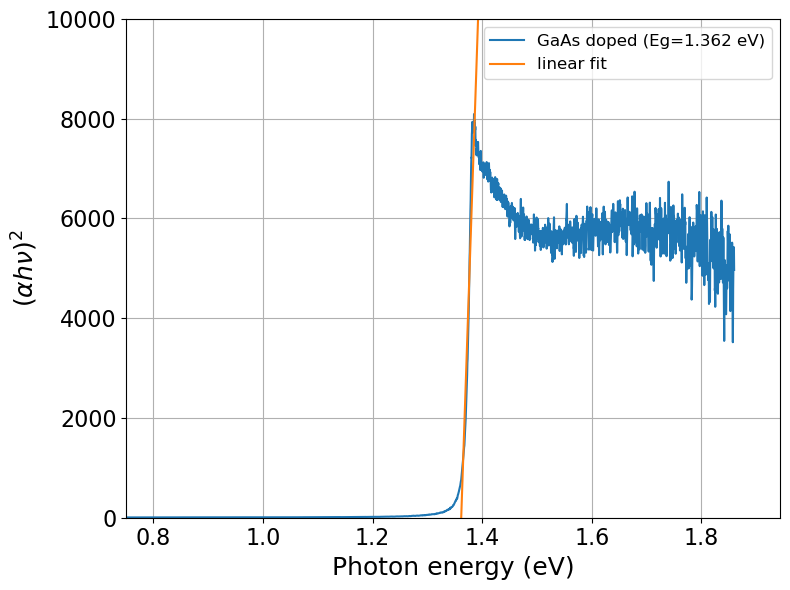

In [63]:
result_si = plot_tauc_from_files(
    transmission_file="transmission/GaAs_Doped_N50_Res4_Trans_Normalized.DPT",
    reflection_file="reflexion/GaAs_Doped_N50_Res4_Reflex_Normalized.DPT",
    thickness_cm=0.044,
    fit_min_eV=1.37,
    fit_max_eV=1.39,
    transition="direct",
    label="GaAs doped"
)

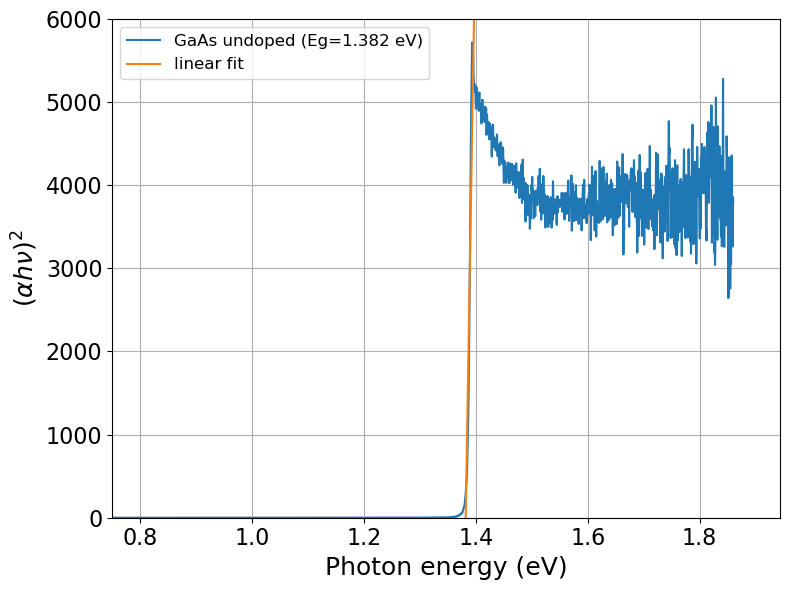

In [61]:
result_si = plot_tauc_from_files(
    transmission_file="transmission/GaAs_unDoped_N50_Res4_Trans_Normalized.DPT",
    reflection_file="reflexion/GaAs_unDoped_N50_Res4_Reflex_Normalized.DPT",
    thickness_cm=0.044,
    fit_min_eV=1.38,
    fit_max_eV=1.392,
    transition="direct",
    label="GaAs undoped"
)

## indirect

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_indirect_tauc_two_fits(
    transmission_file,
    reflection_file,
    thickness_cm,
    fit_range_emission_eV,
    fit_range_absorption_eV,
    label=None,
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0
):
  

    def load_two_column_file(filename, skiprows=0):
        df = pd.read_csv(
            filename,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        if df.shape[1] < 2:
            raise ValueError(f"File '{filename}' must contain at least two columns.")

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber_cm^-1", "value"]
        df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna().sort_values("wavenumber_cm^-1").reset_index(drop=True)

        if df.empty:
            raise ValueError(f"No valid numeric data found in '{filename}'.")

        return df

    def normalize_if_percent(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1.0:
            values = values / 100.0
        return values

    def interpolate_to_common_grid(df_r, df_t):
        wn_r = df_r["wavenumber_cm^-1"].to_numpy()
        r = df_r["value"].to_numpy()

        wn_t = df_t["wavenumber_cm^-1"].to_numpy()
        t = df_t["value"].to_numpy()

        wn_min = max(np.min(wn_r), np.min(wn_t))
        wn_max = min(np.max(wn_r), np.max(wn_t))

        if wn_min >= wn_max:
            raise ValueError("No overlapping wavenumber range between reflection and transmission data.")

        wn_common = np.unique(np.concatenate([
            wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
            wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
        ]))

        r_interp = np.interp(wn_common, wn_r, r)
        t_interp = np.interp(wn_common, wn_t, t)

        return wn_common, r_interp, t_interp

    def alpha_from_R_T(R, T, thickness_cm):
        """
        Incoherent multiple-reflection model:
        T = ((1-R)^2 * x) / (1 - R^2 * x^2), with x = exp(-alpha*d)
        """
        eps = 1e-15

        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        T = np.clip(np.asarray(T, dtype=float), 0.0, 0.999999)

        alpha = np.full_like(R, np.nan, dtype=float)

        mask_r0 = np.abs(R) < 1e-12
        alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

        mask = ~mask_r0
        Rm = R[mask]
        Tm = T[mask]

        a = Tm * Rm**2
        b = (1.0 - Rm)**2
        c = -Tm

        disc = b**2 - 4.0 * a * c
        disc = np.maximum(disc, 0.0)

        x = (-b + np.sqrt(disc)) / (2.0 * a)
        x = np.clip(x, eps, 1.0)

        alpha[mask] = -np.log(x) / thickness_cm
        return alpha

    def energy_from_wavenumber(wavenumber_cm_inv):
        return 1.239841984e-4 * np.asarray(wavenumber_cm_inv, dtype=float)

    def indirect_tauc_y(alpha_cm_inv, energy_eV):
        alpha_hv = np.clip(np.asarray(alpha_cm_inv) * np.asarray(energy_eV), 0.0, None)
        return np.sqrt(alpha_hv)

    def linear_fit_with_intercept(x, y, fit_range):
        xmin, xmax = fit_range
        mask = (
            np.isfinite(x) &
            np.isfinite(y) &
            (x >= xmin) &
            (x <= xmax)
        )

        if np.sum(mask) < 2:
            return {
                "success": False,
                "a": np.nan,
                "b": np.nan,
                "x_fit": np.array([]),
                "y_fit": np.array([]),
                "x_intercept": np.nan
            }

        x_fit = x[mask]
        y_fit = y[mask]
        a, b = np.polyfit(x_fit, y_fit, 1)

        if np.isclose(a, 0.0):
            return {
                "success": False,
                "a": a,
                "b": b,
                "x_fit": x_fit,
                "y_fit": y_fit,
                "x_intercept": np.nan
            }

        x_intercept = -b / a

        return {
            "success": True,
            "a": a,
            "b": b,
            "x_fit": x_fit,
            "y_fit": y_fit,
            "x_intercept": x_intercept
        }

    def style_axes(ax, xlabel, ylabel):
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True)

    if thickness_cm <= 0:
        raise ValueError("thickness_cm must be > 0.")

    df_t = load_two_column_file(transmission_file, skiprows=skiprows_transmission)
    df_r = load_two_column_file(reflection_file, skiprows=skiprows_reflection)

    wn, R, T = interpolate_to_common_grid(df_r, df_t)

    R = normalize_if_percent(R)
    T = normalize_if_percent(T)

    alpha = alpha_from_R_T(R, T, thickness_cm)
    energy_eV = energy_from_wavenumber(wn)
    tauc_y = indirect_tauc_y(alpha, energy_eV)

    fit_em = linear_fit_with_intercept(energy_eV, tauc_y, fit_range_emission_eV)
    fit_ab = linear_fit_with_intercept(energy_eV, tauc_y, fit_range_absorption_eV)

    Eg_eV = np.nan
    Eph_eV = np.nan
    phonon_freq_Hz = np.nan
    phonon_freq_THz = np.nan
    phonon_angular_freq_rad_s = np.nan
    phonon_wavenumber_cm_inv = np.nan

    if fit_em["success"] and fit_ab["success"]:
        x1 = fit_em["x_intercept"]   # ~ Eg - Eph
        x2 = fit_ab["x_intercept"]   # ~ Eg + Eph

        if x2 < x1:
            x1, x2 = x2, x1
            fit_em, fit_ab = fit_ab, fit_em

        Eg_eV = 0.5 * (x1 + x2)
        Eph_eV = 0.5 * (x2 - x1)

        h_eVs = 4.135667696e-15
        hbar_eVs = 6.582119569e-16
        eV_to_cm_inv = 1.0 / 1.239841984e-4

        phonon_freq_Hz = Eph_eV / h_eVs
        phonon_freq_THz = phonon_freq_Hz / 1e12
        phonon_angular_freq_rad_s = Eph_eV / hbar_eVs
        phonon_wavenumber_cm_inv = Eph_eV * eV_to_cm_inv

    fig, ax = plt.subplots(figsize=(8, 6))

    curve_label = label if label is not None else "Sample"
    ax.plot(energy_eV, tauc_y, label=curve_label)

    # draw fit lines across the full energy axis
    if fit_em["success"]:
        ax.plot(energy_eV, fit_em["a"] * energy_eV + fit_em["b"],
                label="Emission fit")
    if fit_ab["success"]:
        ax.plot(energy_eV, fit_ab["a"] * energy_eV + fit_ab["b"],
                label="Absorption fit")

    style_axes(ax, "Photon energy (eV)", r"$(\alpha h\nu)^{1/2}$")
    ax.legend(fontsize=12)
    #ax.set_xlim()
    ax.set_ylim([-1,10])
    plt.tight_layout()
    plt.show()

    if np.isfinite(Eg_eV):
        print(f"Indirect band gap Eg = {Eg_eV:.4f} eV")
        print(f"Phonon energy Eph = {Eph_eV:.4f} eV")
        print(f"Phonon frequency f = {phonon_freq_THz:.4f} THz")
        print(f"Phonon angular frequency ω = {phonon_angular_freq_rad_s:.4e} rad/s")
        print(f"Phonon wavenumber = {phonon_wavenumber_cm_inv:.2f} cm^-1")
    else:
        print("Two-fit indirect-gap extraction not available for the chosen ranges.")

    return {
        "wavenumber_cm^-1": wn,
        "R": R,
        "T": T,
        "alpha_cm^-1": alpha,
        "energy_eV": energy_eV,
        "tauc_y": tauc_y,
        "fit_emission": fit_em,
        "fit_absorption": fit_ab,
        "Eg_eV": Eg_eV,
        "Eph_eV": Eph_eV,
        "phonon_frequency_Hz": phonon_freq_Hz,
        "phonon_frequency_THz": phonon_freq_THz,
        "phonon_angular_frequency_rad_s": phonon_angular_freq_rad_s,
        "phonon_wavenumber_cm^-1": phonon_wavenumber_cm_inv
    }

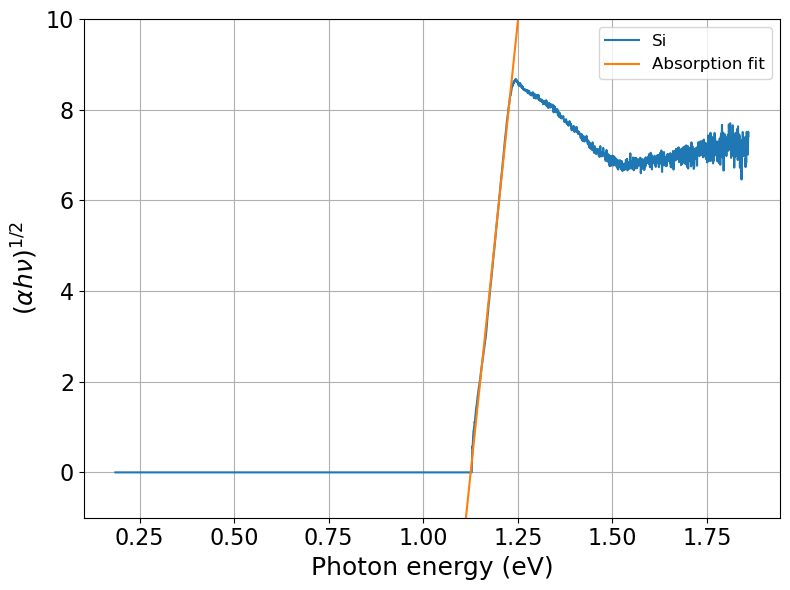

Two-fit indirect-gap extraction not available for the chosen ranges.


In [91]:


result_si = plot_indirect_tauc_two_fits(
    transmission_file="transmission/Si_unDoped_N50_Res4_Trans_Normalized.DPT",
    reflection_file="reflexion/Si_unDoped_N50_Res4_Reflex_Normalized.DPT",
    thickness_cm=0.05,
    fit_range_emission_eV=(1.02, 1.10),
    fit_range_absorption_eV=(1.14, 1.22),
    label="Si"
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_indirect_tauc_vs_wavenumber(
    transmission_file,
    reflection_file,
    thickness_cm,
    fit_range_1_cm_inv,
    fit_range_2_cm_inv,
    label=None,
    decimal='.',
    comment='#',
    skiprows_transmission=0,
    skiprows_reflection=0,
    use_literal_beta_nu2=True
):


    def load_two_column_file(filename, skiprows=0):
        df = pd.read_csv(
            filename,
            sep=None,
            engine="python",
            header=None,
            skiprows=skiprows,
            decimal=decimal,
            comment=comment
        )

        if df.shape[1] < 2:
            raise ValueError(f"File '{filename}' must contain at least two columns.")

        df = df.iloc[:, :2].copy()
        df.columns = ["wavenumber_cm^-1", "value"]
        df["wavenumber_cm^-1"] = pd.to_numeric(df["wavenumber_cm^-1"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna().sort_values("wavenumber_cm^-1").reset_index(drop=True)

        if df.empty:
            raise ValueError(f"No valid numeric data found in '{filename}'.")

        return df

    def normalize_if_percent(values):
        values = np.asarray(values, dtype=float)
        if np.nanmax(values) > 1.0:
            values = values / 100.0
        return values

    def interpolate_to_common_grid(df_r, df_t):
        wn_r = df_r["wavenumber_cm^-1"].to_numpy()
        r = df_r["value"].to_numpy()

        wn_t = df_t["wavenumber_cm^-1"].to_numpy()
        t = df_t["value"].to_numpy()

        wn_min = max(np.min(wn_r), np.min(wn_t))
        wn_max = min(np.max(wn_r), np.max(wn_t))

        if wn_min >= wn_max:
            raise ValueError("No overlapping wavenumber range between reflection and transmission data.")

        wn_common = np.unique(np.concatenate([
            wn_r[(wn_r >= wn_min) & (wn_r <= wn_max)],
            wn_t[(wn_t >= wn_min) & (wn_t <= wn_max)]
        ]))

        r_interp = np.interp(wn_common, wn_r, r)
        t_interp = np.interp(wn_common, wn_t, t)

        return wn_common, r_interp, t_interp

    def alpha_from_R_T(R, T, thickness_cm):
        eps = 1e-15

        R = np.clip(np.asarray(R, dtype=float), 0.0, 0.999999)
        T = np.clip(np.asarray(T, dtype=float), 0.0, 0.999999)

        alpha = np.full_like(R, np.nan, dtype=float)

        mask_r0 = np.abs(R) < 1e-12
        alpha[mask_r0] = -np.log(np.clip(T[mask_r0], eps, 1.0)) / thickness_cm

        mask = ~mask_r0
        Rm = R[mask]
        Tm = T[mask]

        a = Tm * Rm**2
        b = (1.0 - Rm)**2
        c = -Tm

        disc = b**2 - 4.0 * a * c
        disc = np.maximum(disc, 0.0)

        x = (-b + np.sqrt(disc)) / (2.0 * a)
        x = np.clip(x, eps, 1.0)

        alpha[mask] = -np.log(x) / thickness_cm
        return alpha

    def energy_from_wavenumber(wavenumber_cm_inv):
        return 1.239841984e-4 * np.asarray(wavenumber_cm_inv, dtype=float)

    def indirect_y(beta_cm_inv, wavenumber_cm_inv):
        beta_cm_inv = np.asarray(beta_cm_inv, dtype=float)
        wn = np.asarray(wavenumber_cm_inv, dtype=float)

        if use_literal_beta_nu2:
            y = np.sqrt(np.clip(beta_cm_inv * wn**2, 0.0, None))
        else:
            energy_eV = energy_from_wavenumber(wn)
            y = np.sqrt(np.clip(beta_cm_inv * energy_eV, 0.0, None))
        return y

    def linear_fit_with_intercept(x, y, fit_range):
        xmin, xmax = fit_range
        mask = (
            np.isfinite(x) &
            np.isfinite(y) &
            (x >= xmin) &
            (x <= xmax)
        )

        if np.sum(mask) < 2:
            return {
                "success": False,
                "a": np.nan,
                "b": np.nan,
                "x_fit": np.array([]),
                "y_fit": np.array([]),
                "x_intercept": np.nan
            }

        x_fit = x[mask]
        y_fit = y[mask]
        a, b = np.polyfit(x_fit, y_fit, 1)

        if np.isclose(a, 0.0):
            return {
                "success": False,
                "a": a,
                "b": b,
                "x_fit": x_fit,
                "y_fit": y_fit,
                "x_intercept": np.nan
            }

        x_intercept = -b / a

        return {
            "success": True,
            "a": a,
            "b": b,
            "x_fit": x_fit,
            "y_fit": y_fit,
            "x_intercept": x_intercept
        }

    def style_axes(ax, xlabel, ylabel):
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True)

    if thickness_cm <= 0:
        raise ValueError("thickness_cm must be > 0.")

    df_t = load_two_column_file(transmission_file, skiprows=skiprows_transmission)
    df_r = load_two_column_file(reflection_file, skiprows=skiprows_reflection)

    wn, R, T = interpolate_to_common_grid(df_r, df_t)

    R = normalize_if_percent(R)
    T = normalize_if_percent(T)

    beta = alpha_from_R_T(R, T, thickness_cm)   # beta = absorption coefficient
    y = indirect_y(beta, wn)

    fit_1 = linear_fit_with_intercept(wn, y, fit_range_1_cm_inv)
    fit_2 = linear_fit_with_intercept(wn, y, fit_range_2_cm_inv)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_ylim([-1,10])

    curve_label = label if label is not None else "Sample"
    ax.plot(wn, y, label=curve_label)

    if fit_1["success"]:
        ax.plot(wn, fit_1["a"] * wn + fit_1["b"], label="Fit 1")
    if fit_2["success"]:
        ax.plot(wn, fit_2["a"] * wn + fit_2["b"], label="Fit 2")

    if use_literal_beta_nu2:
        ylabel = r"$(\beta \tilde{\nu}^{2})^{1/2}$"
    else:
        ylabel = r"$(\beta h\nu)^{1/2}$"

    style_axes(ax, r"Wavenumber (cm$^{-1}$)", ylabel)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    return {
        "wavenumber_cm^-1": wn,
        "R": R,
        "T": T,
        "beta_cm^-1": beta,
        "y": y,
        "fit_1": fit_1,
        "fit_2": fit_2
    }

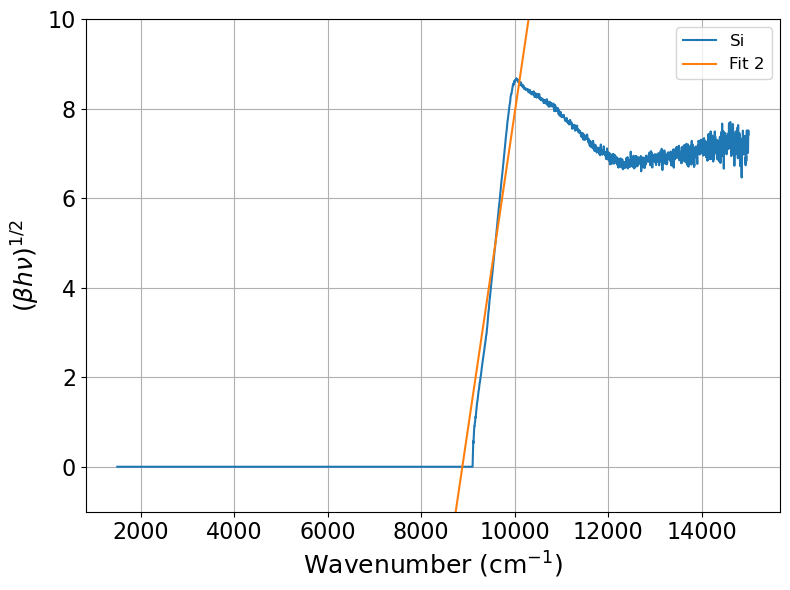

In [104]:
res = plot_indirect_tauc_vs_wavenumber(
    transmission_file="transmission/Si_unDoped_N50_Res4_Trans_Normalized.DPT",
    reflection_file="reflexion/Si_unDoped_N50_Res4_Reflex_Normalized.DPT",
    thickness_cm=0.05,
    fit_range_1_cm_inv=(8000, 9000),
    fit_range_2_cm_inv=(9300, 10300),
    label="Si",
    use_literal_beta_nu2=False
)

## Simulation

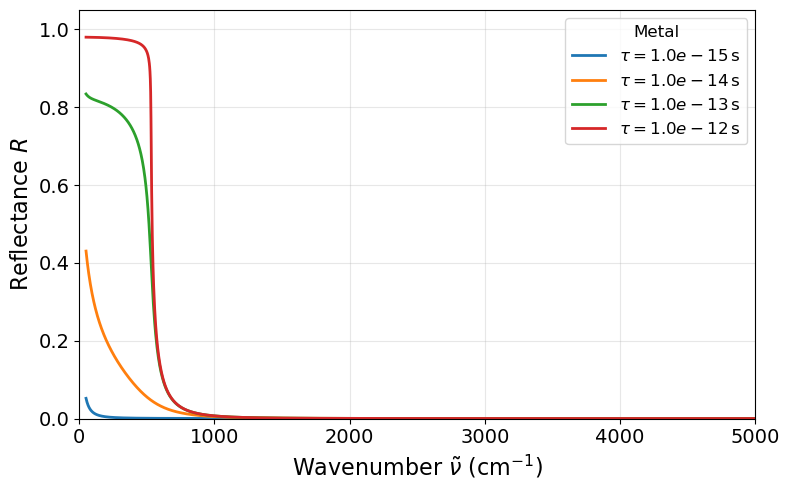

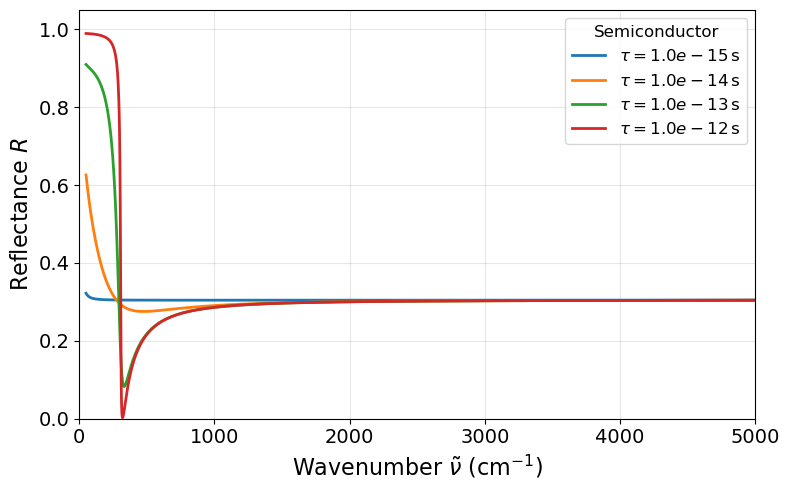

In [111]:
import numpy as np
import matplotlib.pyplot as plt


def drude_epsilon(omega, omega_p, tau, eps_inf=1.0):
    """
    Complex dielectric function in the Drude model.

    Parameters
    ----------
    omega : array_like
        Angular frequency in rad/s
    omega_p : float
        Plasma frequency in rad/s
    tau : float
        Relaxation time in s
    eps_inf : float
        High-frequency dielectric constant

    Returns
    -------
    epsilon : ndarray
        Complex dielectric function
    """
    gamma = 1.0 / tau
    return eps_inf - omega_p**2 / (omega**2 + 1j * gamma * omega)


def reflectance_from_epsilon(epsilon):
    """
    Computes reflectance at normal incidence from epsilon.
    """
    n_complex = np.sqrt(epsilon)
    r = (n_complex - 1.0) / (n_complex + 1.0)
    return np.abs(r)**2


def drude_reflectance_vs_wavenumber(wavenumber_cm, omega_p, tau, eps_inf=1.0):
    """
    Computes reflectance as a function of wavenumber.

    Parameters
    ----------
    wavenumber_cm : array_like
        Wavenumber in cm^-1
    omega_p : float
        Plasma frequency in rad/s
    tau : float
        Relaxation time in s
    eps_inf : float
        High-frequency dielectric constant

    Returns
    -------
    R : ndarray
        Reflectance
    """
    c_cm_s = 2.99792458e10  # speed of light in cm/s
    omega = 2.0 * np.pi * c_cm_s * np.asarray(wavenumber_cm)

    epsilon = drude_epsilon(omega, omega_p, tau, eps_inf=eps_inf)
    R = reflectance_from_epsilon(epsilon)
    return R


def plot_drude_reflectance_set(
    wavenumber_min,
    wavenumber_max,
    num_points,
    omega_p,
    eps_inf,
    taus,
    legend_title=None
):
    """
    Plots Drude reflectance for a set of relaxation times.
    """
    wavenumber_cm = np.linspace(wavenumber_min, wavenumber_max, num_points)

    plt.figure(figsize=(8, 5))

    for tau in taus:
        R = drude_reflectance_vs_wavenumber(
            wavenumber_cm=wavenumber_cm,
            omega_p=omega_p,
            tau=tau,
            eps_inf=eps_inf
        )
        plt.plot(wavenumber_cm, R, linewidth=2, label=fr"$\tau = {tau:.1e}\,$s")

    plt.xlabel(r"Wavenumber $\tilde{\nu}$ (cm$^{-1}$)", fontsize=16)
    plt.ylabel("Reflectance $R$", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12, title=legend_title, title_fontsize=12)
    plt.ylim(0, 1.05)
    plt.xlim(0, 5000)
    plt.tight_layout()
    plt.show()

taus=(1e-15, 1e-14, 1e-13, 1e-12)
if __name__ == "__main__":
    # -----------------------------
    # Example 1: Metal
    # -----------------------------
    # Typical Drude-like behavior:
    # high plasma frequency, relatively short scattering times
    plot_drude_reflectance_set(
        wavenumber_min=50,
        wavenumber_max=5000,
        num_points=2000,
        omega_p=1.0e14,          # example metal plasma frequency [rad/s]
        eps_inf=1.0,
        taus=taus,
        legend_title="Metal"
    )

    # -----------------------------
    # Example 2: Semiconductor
    # -----------------------------
    # Lower free-carrier density -> lower plasma frequency
    plot_drude_reflectance_set(
        wavenumber_min=50,
        wavenumber_max=5000,
        num_points=2000,
        omega_p=2.0e14,          # example semiconductor plasma frequency [rad/s]
        eps_inf=12.0,
        taus=taus,
        legend_title="Semiconductor"
    )